In [18]:
# import pandas as pd

# # Correct Kaggle path
# file_path = "/kaggle/input/datasets/rick2324/nifty-50-full-features"

# df = pd.read_csv(file_path)

# print(df.shape)
# df.head()
import os
import pandas as pd

folder = "/kaggle/input/datasets/rick2324/nifty-50-full-features"

print(os.listdir(folder))

file_path = folder + "/" + os.listdir(folder)[0]

df = pd.read_csv(file_path)

print(df.shape)
df.head()

['nifty50_full_features.csv']
(3978, 16)


,Date,Close,High,Low,Open,Volume,Adj_Close,Daily_Return,Log_Return,Volatility,MA_20,MA_50,RSI,MACD,MACD_signal,Next_Return
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0,5232.200195,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.008734
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,5277.899902,0.008734,0.008696,NaN,NaN,NaN,NaN,3.645561,0.729112,0.000739
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,5281.799805,0.000739,0.000739,NaN,NaN,NaN,NaN,6.771328,1.937555,-0.003540
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,5263.100098,-0.003540,-0.003547,NaN,NaN,NaN,NaN,7.651410,3.080326,-0.003487
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,5244.750000,-0.003487,-0.003493,NaN,NaN,NaN,NaN,6.789912,3.822243,0.000887


🧱 📂 CELL 1 — Load Data

In [19]:
# import pandas as pd

# file_path = "/kaggle/input/datasets/rohitonboard/nifty50/nifty50_features.csv"
# df = pd.read_csv(file_path)

# df["Date"] = pd.to_datetime(df["Date"])

# print("Shape:", df.shape)
# df.head()

# Cell 1 — Load Dataset

# Cell 1 — Load Dataset

import pandas as pd
import os

# dataset folder
folder = "/kaggle/input/datasets/rick2324/nifty-50-full-features"

# check files in folder
print("Files in folder:", os.listdir(folder))

# correct csv path
file_path = folder + "/nifty50_full_features.csv"

# load dataset
df = pd.read_csv(file_path)

# convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# sort by date (important for time series)
df = df.sort_values("Date")

print("Dataset Shape:", df.shape)

df.head()


Files in folder: ['nifty50_full_features.csv']
Dataset Shape: (3978, 16)


,Date,Close,High,Low,Open,Volume,Adj_Close,Daily_Return,Log_Return,Volatility,MA_20,MA_50,RSI,MACD,MACD_signal,Next_Return
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0,5232.200195,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.008734
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,5277.899902,0.008734,0.008696,NaN,NaN,NaN,NaN,3.645561,0.729112,0.000739
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,5281.799805,0.000739,0.000739,NaN,NaN,NaN,NaN,6.771328,1.937555,-0.003540
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,5263.100098,-0.003540,-0.003547,NaN,NaN,NaN,NaN,7.651410,3.080326,-0.003487
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,5244.750000,-0.003487,-0.003493,NaN,NaN,NaN,NaN,6.789912,3.822243,0.000887


📊 📈 CELL 2 — Price Trend

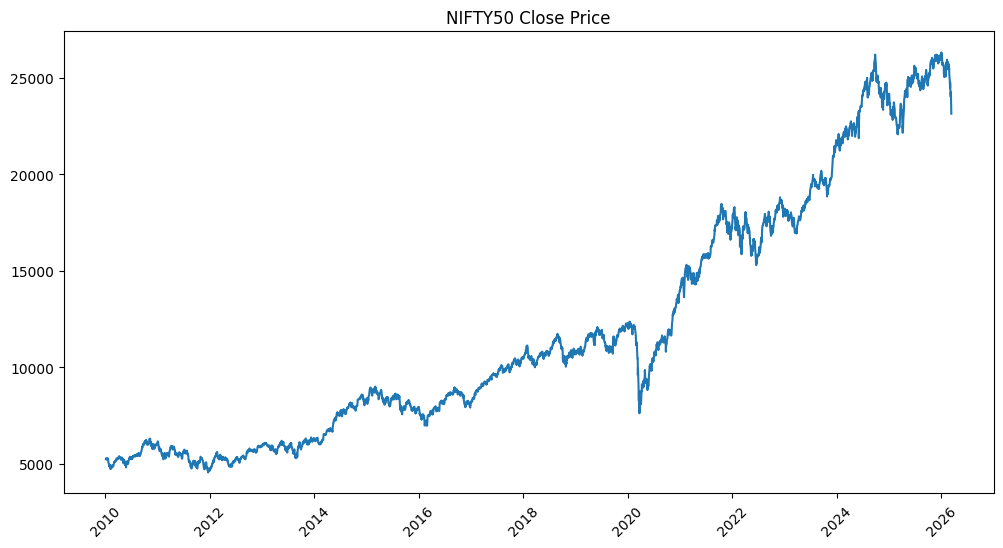

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("NIFTY50 Close Price")
plt.xticks(rotation=45)
plt.show()

📊 📉 CELL 3 — Return Distribution

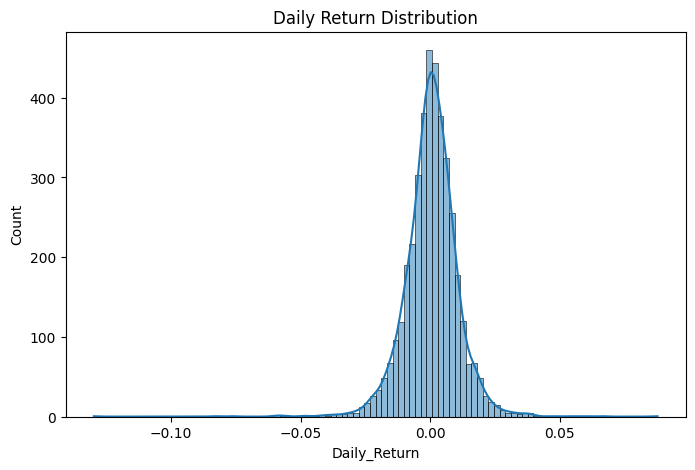

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Return"], bins=100, kde=True)
plt.title("Daily Return Distribution")
plt.show()

🔥 📊 CELL 4 — Pearson Heatmap

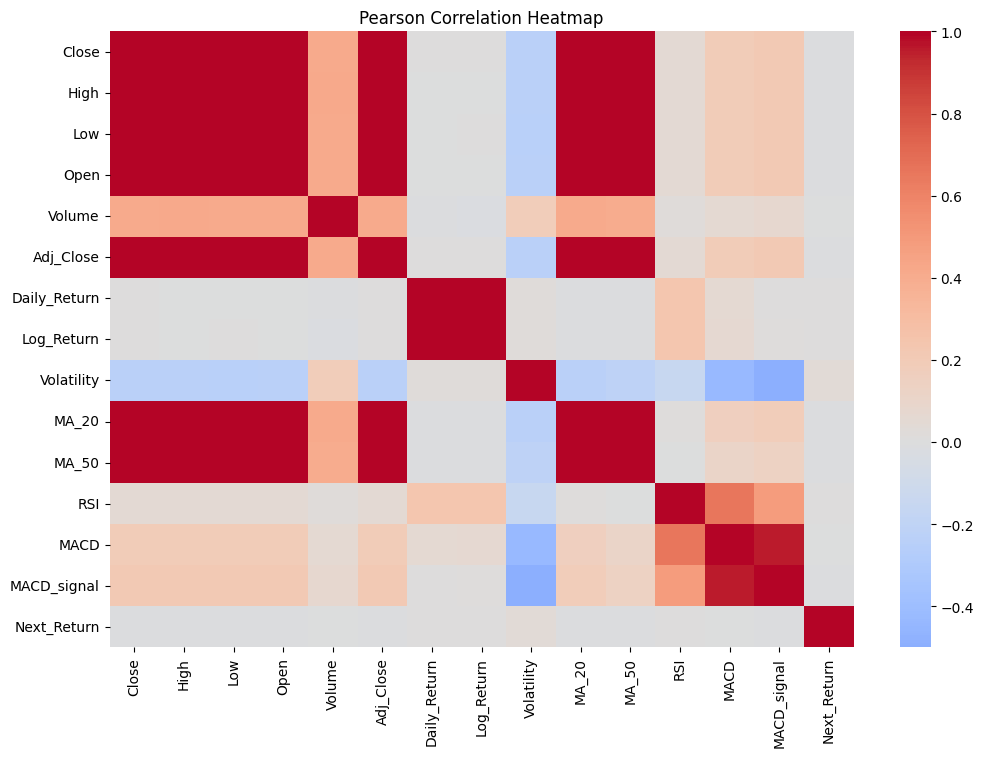

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(method="pearson", numeric_only=True), cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

🔥 📊 CELL 5 — Spearman Heatmap

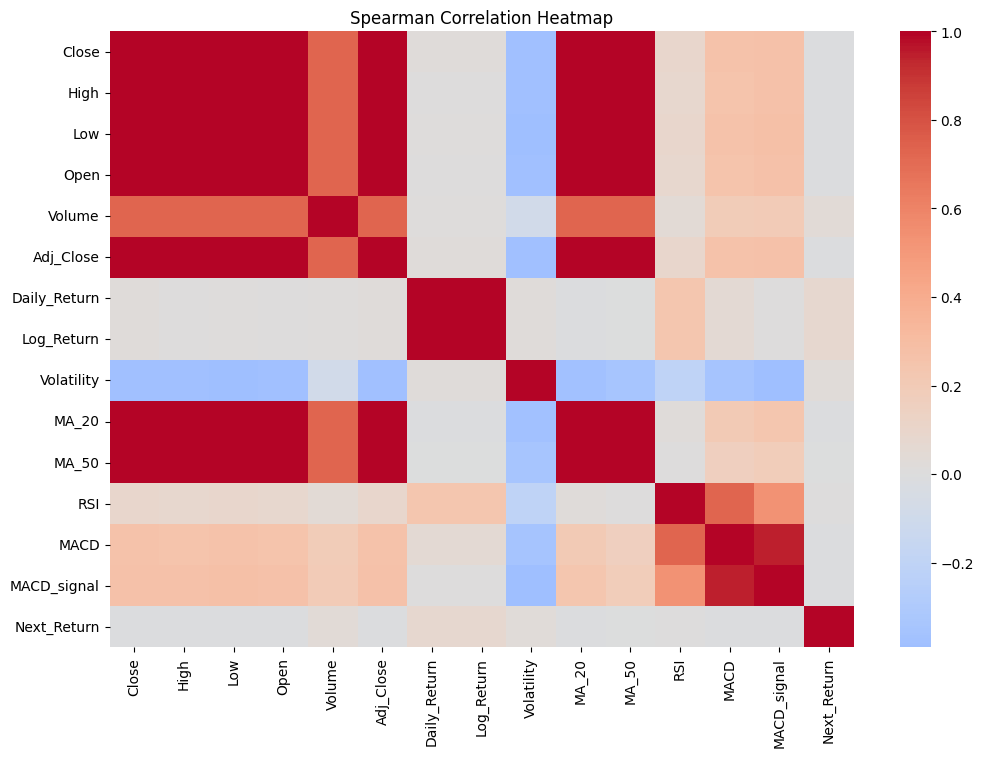

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(method="spearman", numeric_only=True), cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap")
plt.show()

📊 🎯 CELL 6 — Correlation with Target

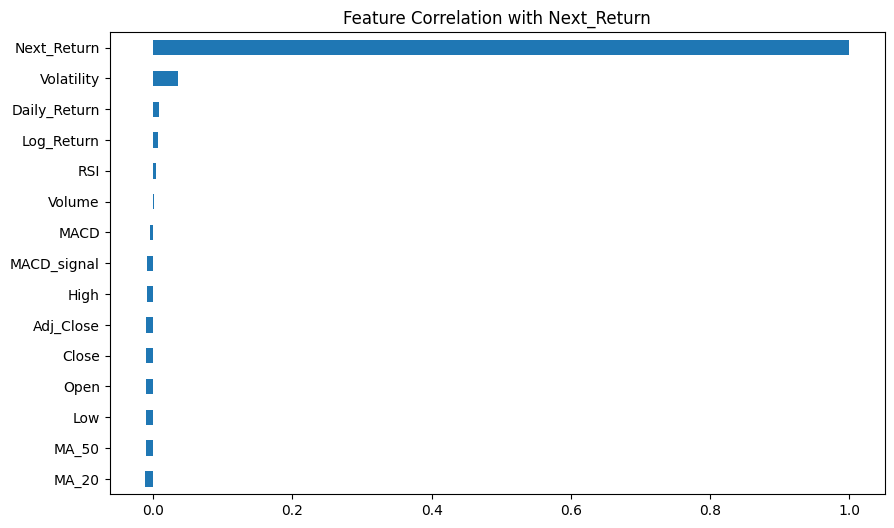

In [24]:
pearson_target = df.corr(method="pearson", numeric_only=True)["Next_Return"].sort_values()

plt.figure(figsize=(10,6))
pearson_target.plot(kind="barh")
plt.title("Feature Correlation with Next_Return")
plt.show()

🤖 📂 CELL 7 — Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

# Create classification target (1 = market up, 0 = market down)
df["Next_Direction"] = (df["Next_Return"] > 0).astype(int)

# Features and target
features = df.drop(columns=["Date", "Next_Return", "Next_Direction"])
target = df["Next_Direction"]

# Train test split (important: shuffle=False for time series)
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, shuffle=False
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3182, 14)
Test shape: (796, 14)


🤖 🚀 CELL 8 — Train Model

In [27]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.03,
    tree_method="hist"
)

model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


📊 📉 CELL 9 — Accuracy + Confusion Matrix

Accuracy: 0.4949748743718593


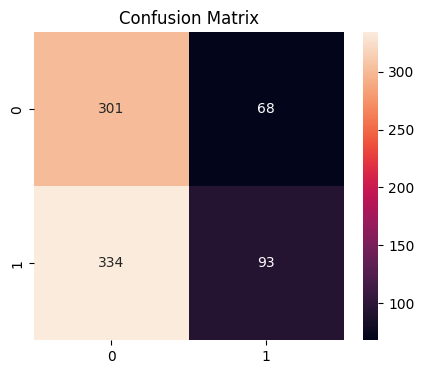

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

📈 💰 CELL 10 — Strategy vs Market

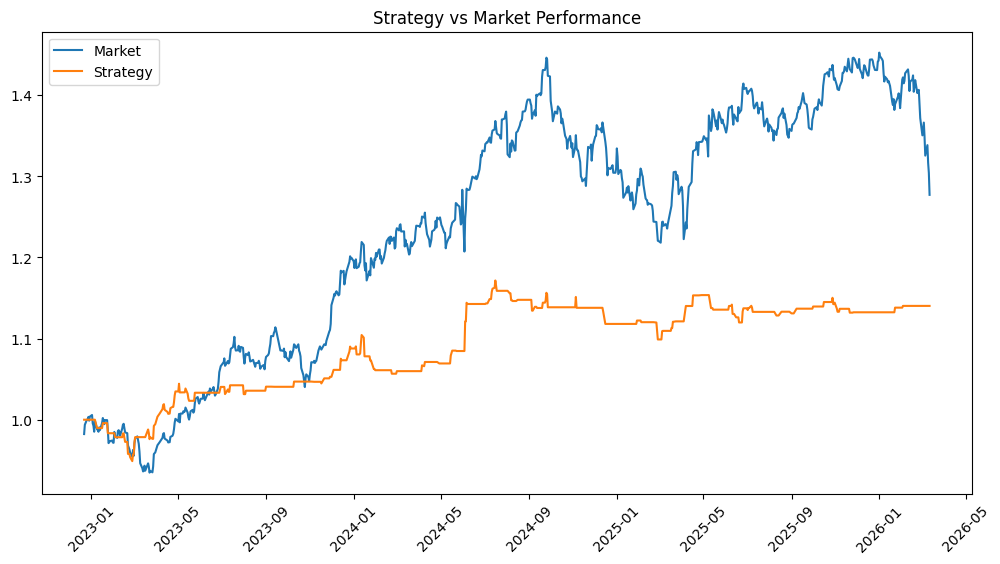

In [29]:
df_test = df.iloc[len(X_train):].copy()
df_test["Prediction"] = preds

df_test["Strategy_Return"] = df_test["Prediction"] * df_test["Next_Return"]

df_test["Cumulative_Market"] = (1 + df_test["Next_Return"]).cumprod()
df_test["Cumulative_Strategy"] = (1 + df_test["Strategy_Return"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df_test["Date"], df_test["Cumulative_Market"], label="Market")
plt.plot(df_test["Date"], df_test["Cumulative_Strategy"], label="Strategy")
plt.legend()
plt.title("Strategy vs Market Performance")
plt.xticks(rotation=45)
plt.show()

📉 📊 CELL 11 — Rolling Accuracy

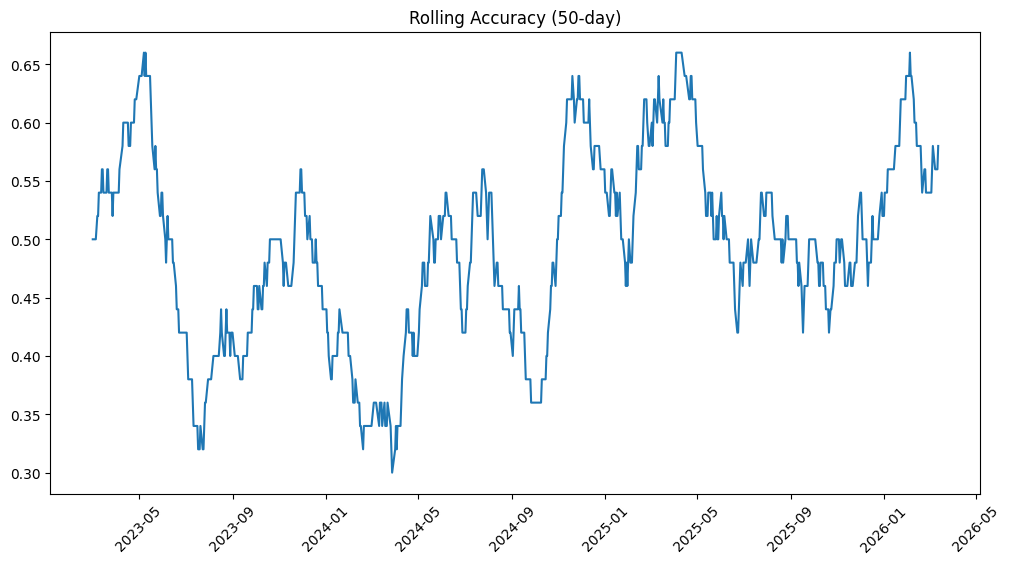

In [30]:
df_test["Correct"] = (df_test["Prediction"] == df_test["Next_Direction"]).astype(int)
df_test["Rolling_Accuracy"] = df_test["Correct"].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df_test["Date"], df_test["Rolling_Accuracy"])
plt.title("Rolling Accuracy (50-day)"),.
plt.xticks(rotation=45)
plt.show()

🤖 🔥 CELL 12 — SHAP

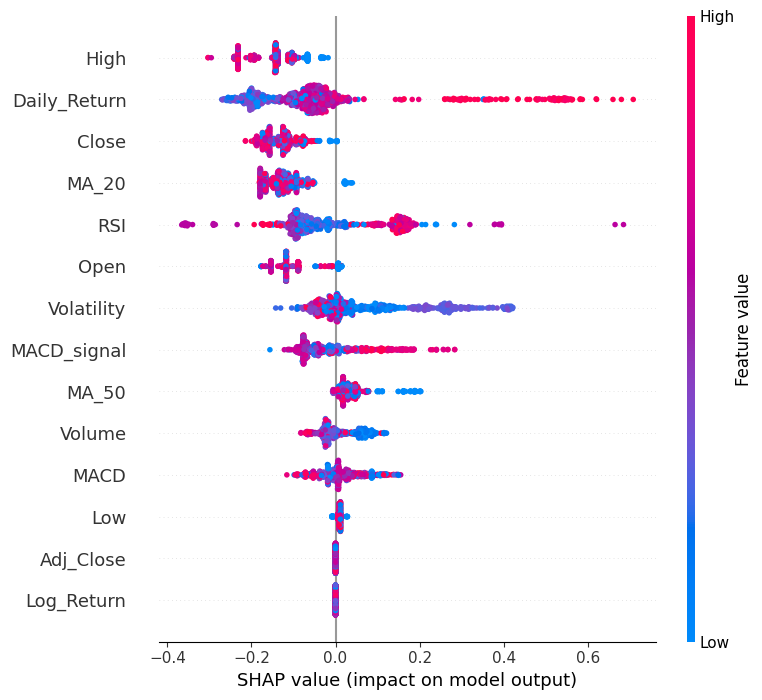

In [31]:
!pip install shap
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

📦 🤖 CELL 13 — Install LIME

In [32]:
!pip install lime

🧠 📊 CELL 14 — Setup LIME

In [33]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Down", "Up"],
    mode="classification"
)

print("LIME ready ✅")

LIME ready ✅


Data Cleaning for LIME

In [36]:
# Clean dataset for LIME (remove NaN rows)

df = df.dropna().reset_index(drop=True)

# recreate target column
df["Next_Direction"] = (df["Next_Return"] > 0).astype(int)

# recreate features and target
features = df.drop(columns=["Date", "Next_Return", "Next_Direction"])
target = df["Next_Direction"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    shuffle=False
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# retrain model because dataset changed
model.fit(X_train, y_train)

Train shape: (3142, 14)
Test shape: (786, 14)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

Rereunning the model


In [39]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

🔍 📊 CELL 15 — LIME Explanation (Single)

In [41]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=["Down", "Up"],
    mode="classification"
)

i = 10  # sample index

exp = explainer_lime.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)

📊 📉 CELL 16 — LIME Plot

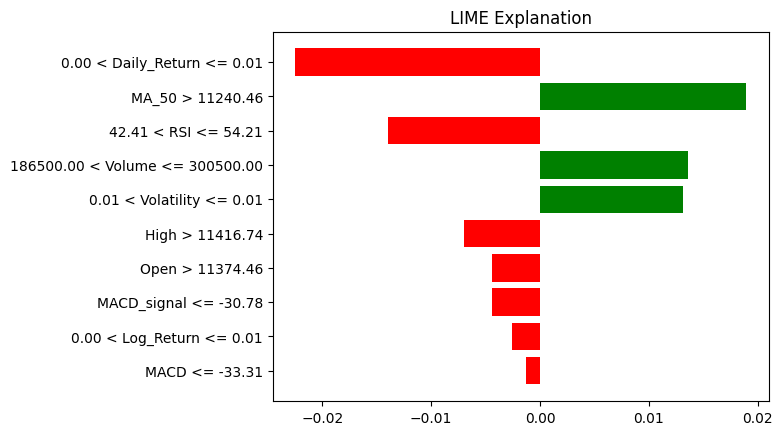

In [42]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
plt.title("LIME Explanation")
plt.show()

📊 Cell 17 — Correlation Matrix (Market Structure)

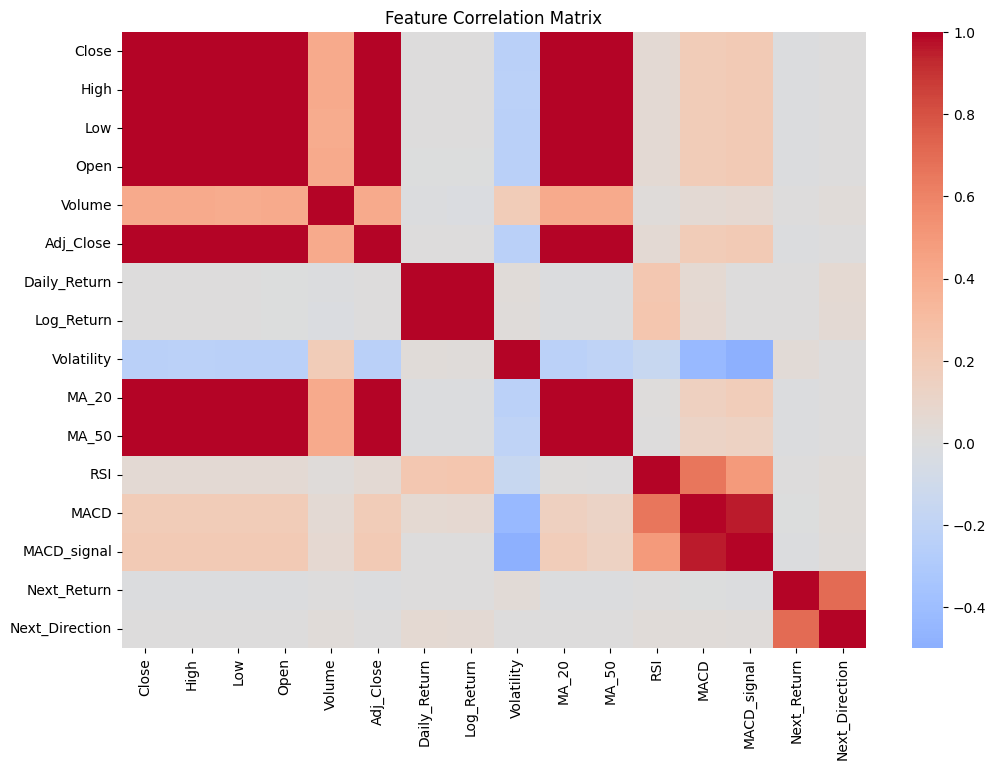

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.drop(columns=["Date"]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

📊 Cell 18 — Pearson Correlation Graph

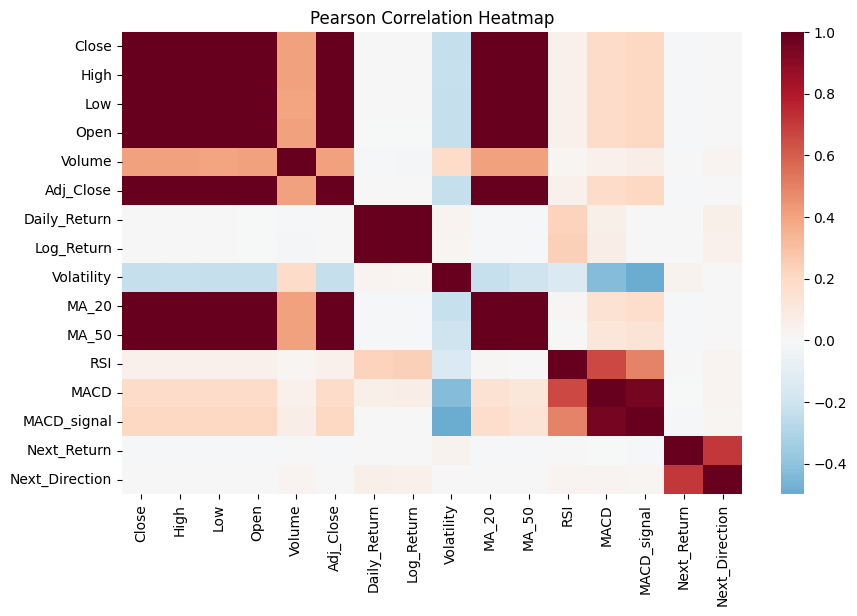

In [44]:
pearson_corr = df.drop(columns=["Date"]).corr(method="pearson")

plt.figure(figsize=(10,6))
sns.heatmap(pearson_corr, cmap="RdBu_r", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

Spearman Correlation Graph

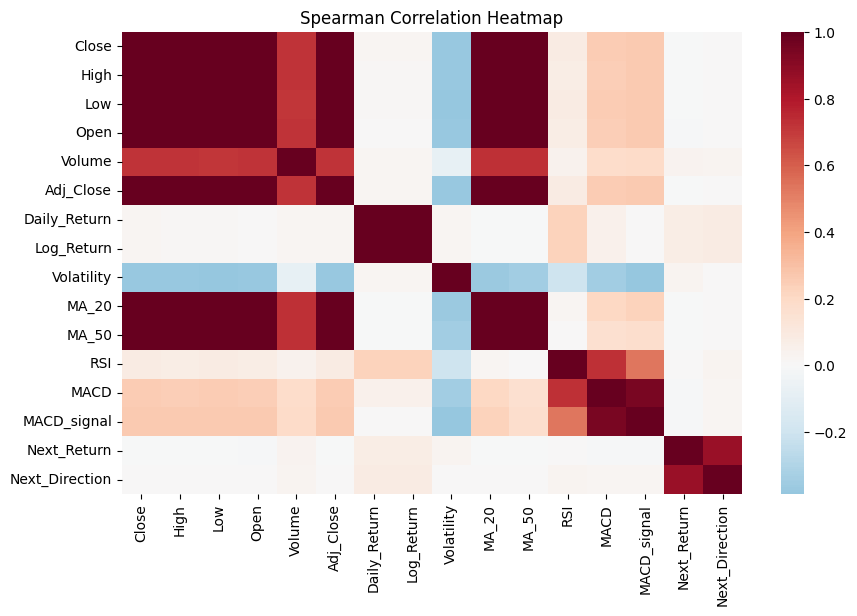

In [45]:
spearman_corr = df.drop(columns=["Date"]).corr(method="spearman")

plt.figure(figsize=(10,6))
sns.heatmap(spearman_corr, cmap="RdBu_r", center=0)
plt.title("Spearman Correlation Heatmap")
plt.show()

Eigenvalue Analysis (Market Dominance)

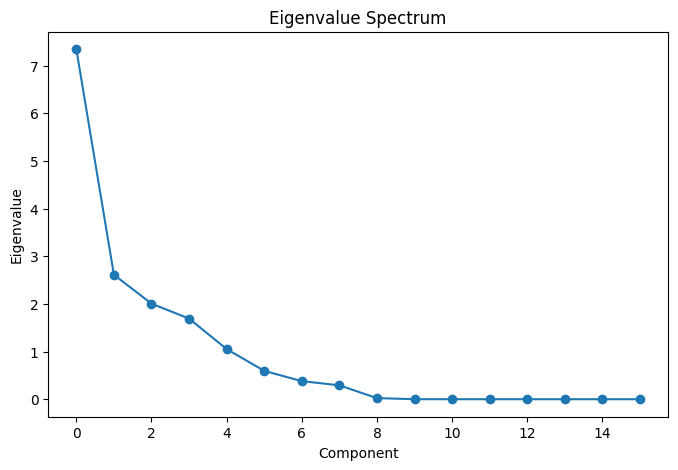

In [46]:
import numpy as np

corr = df.drop(columns=["Date"]).corr()

eigenvalues, eigenvectors = np.linalg.eig(corr)

plt.figure(figsize=(8,5))
plt.plot(sorted(eigenvalues, reverse=True), marker='o')
plt.title("Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

📊 Cell 21 — PCA (Factor Structure)

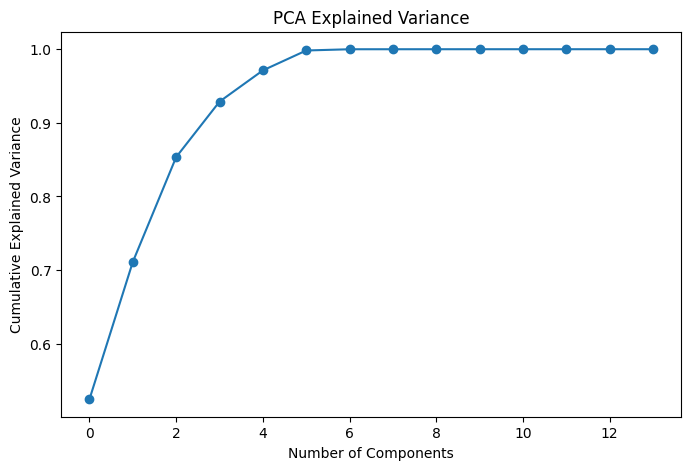

In [47]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features_only = df.drop(columns=["Date","Next_Return","Next_Direction"])

scaled = StandardScaler().fit_transform(features_only)

pca = PCA()
pca.fit(scaled)

plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show() #SVM 

📊 Cell 22 — Hierarchical Clustering (Dendrogram)

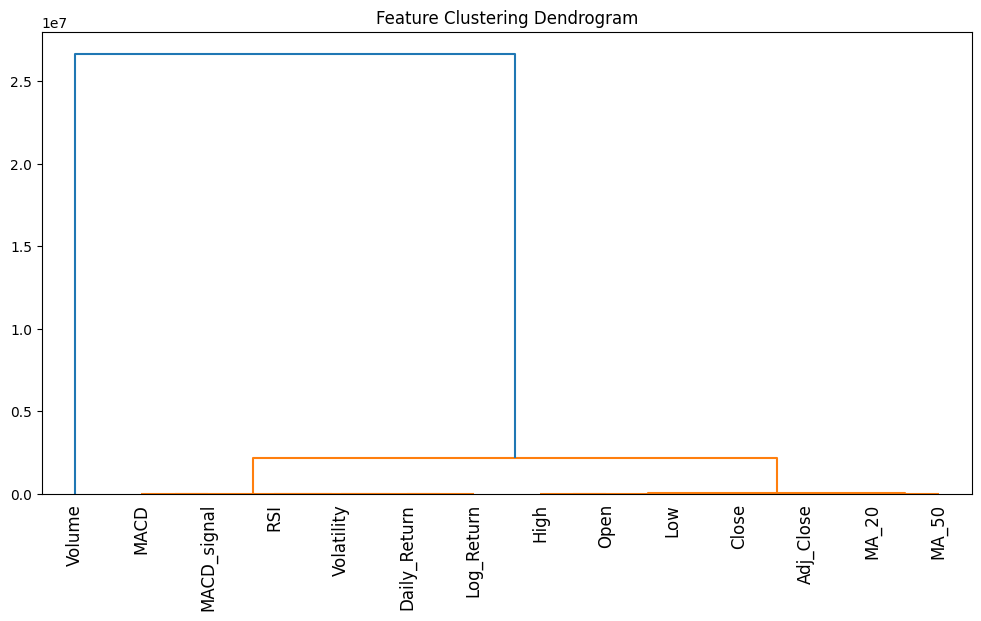

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(features_only.T, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, labels=features_only.columns)
plt.title("Feature Clustering Dendrogram")
plt.xticks(rotation=90)
plt.show()

📊 Cell 23 — Rolling Volatility (Time‑Varying Market)

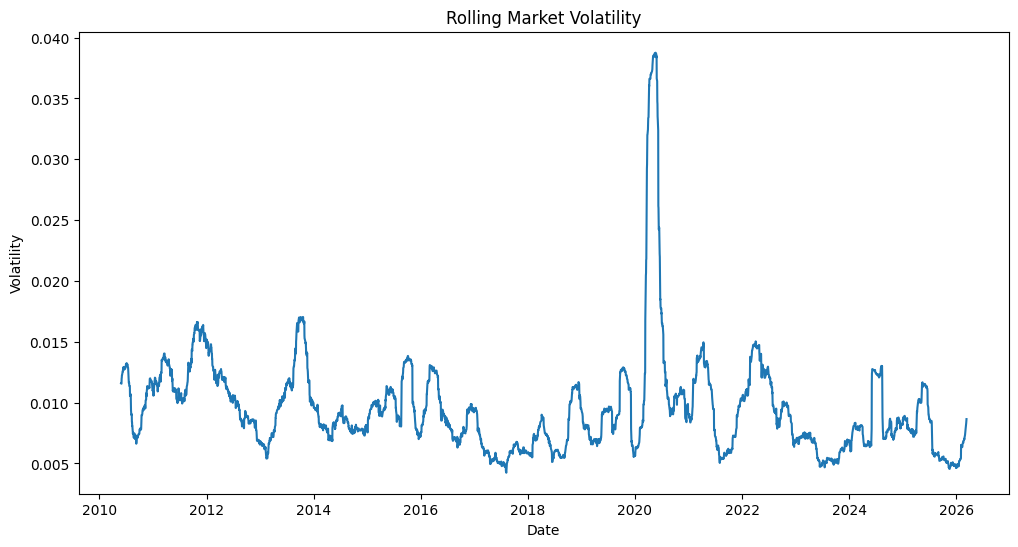

In [49]:
df["Rolling_Volatility"] = df["Daily_Return"].rolling(50).std()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Rolling_Volatility"])
plt.title("Rolling Market Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

📊 Cell 24 — Time Period Comparison

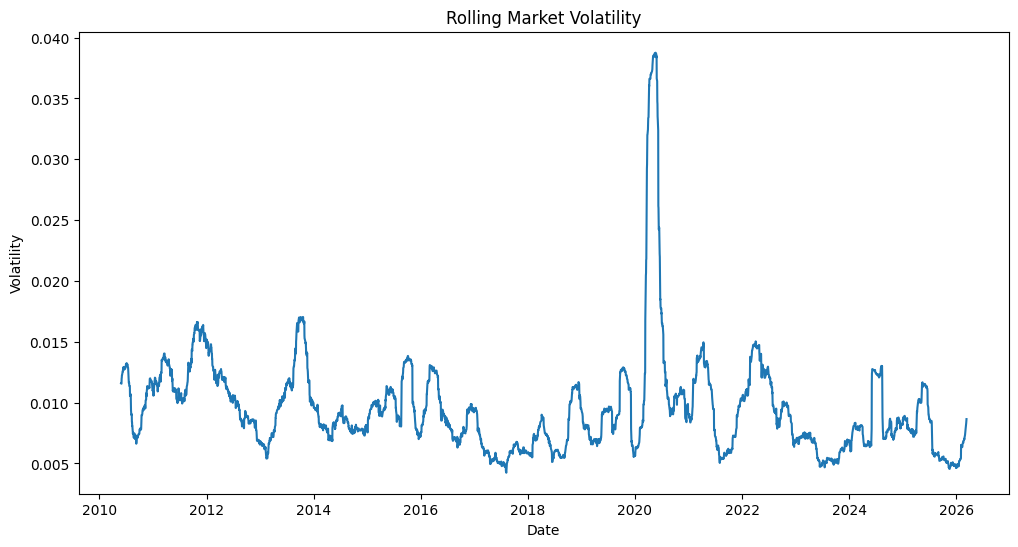

In [50]:
df["Rolling_Volatility"] = df["Daily_Return"].rolling(50).std()
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Rolling_Volatility"])
plt.title("Rolling Market Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

📊 Cell 28 — Compare Correlation, Volatility, Eigenvalues

In [51]:
import numpy as np

# Define periods
period1 = df[(df["Date"] >= "2010-01-01") & (df["Date"] <= "2019-12-31")]
period2 = df[(df["Date"] >= "2020-01-01") & (df["Date"] <= "2020-12-31")]
period3 = df[(df["Date"] >= "2021-01-01")]

def analyze_period(data, name):
    
    # Correlation
    corr_matrix = data.drop(columns=["Date"]).corr()
    avg_corr = corr_matrix.mean().mean()
    
    # Volatility
    volatility = data["Daily_Return"].std()
    
    # Eigenvalues
    eigenvalues = np.linalg.eigvals(corr_matrix)
    largest_eigen = max(eigenvalues)
    
    print(f"\n{name}")
    print("Average Correlation:", avg_corr)
    print("Volatility:", volatility)
    print("Largest Eigenvalue:", largest_eigen)

analyze_period(period1, "2010–2019 (Normal Market)")
analyze_period(period2, "2020 (COVID Crash)")
analyze_period(period3, "2021+ (Recovery)")


2010–2019 (Normal Market)
Average Correlation: 0.24100514590190134
Volatility: 0.009720458464306284
Largest Eigenvalue: 8.223841610031606

2020 (COVID Crash)
Average Correlation: 0.18483259970600105
Volatility: 0.019735408959048174
Largest Eigenvalue: 9.070960322555822

2021+ (Recovery)
Average Correlation: 0.19418362768495379
Volatility: 0.008815006432633958
Largest Eigenvalue: 7.3110644277187


📊 Cell 29 — Market Phases Visualization (Normal vs COVID vs Recovery)

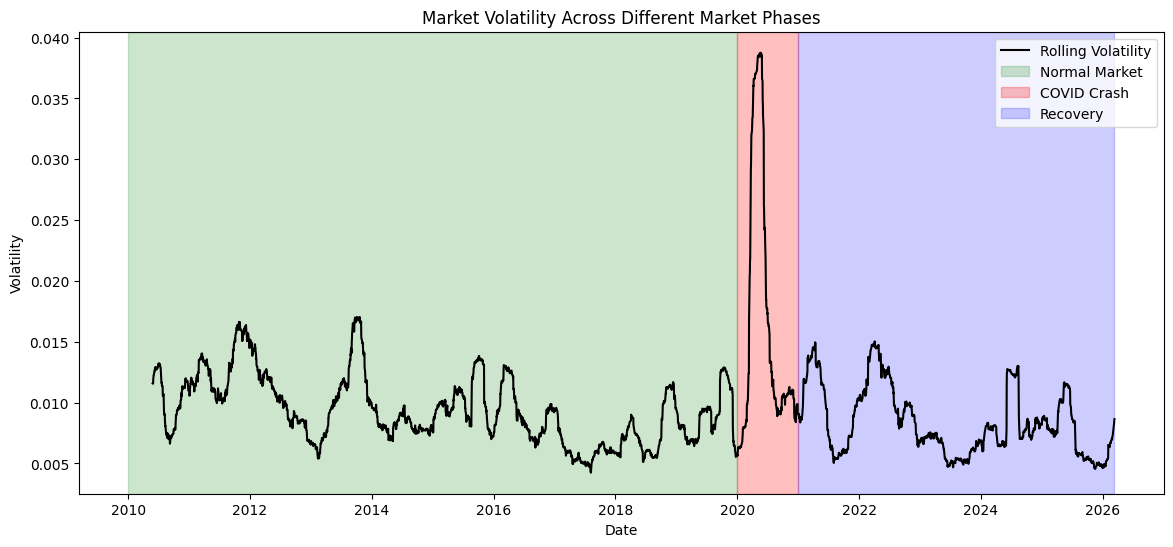

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Rolling_Volatility"], label="Rolling Volatility", color="black")

# Normal market
plt.axvspan(pd.to_datetime("2010-01-01"), pd.to_datetime("2019-12-31"),
            color="green", alpha=0.2, label="Normal Market")

# COVID crash
plt.axvspan(pd.to_datetime("2020-01-01"), pd.to_datetime("2020-12-31"),
            color="red", alpha=0.25, label="COVID Crash")

# Recovery period
plt.axvspan(pd.to_datetime("2021-01-01"), df["Date"].max(),
            color="blue", alpha=0.2, label="Recovery")

plt.title("Market Volatility Across Different Market Phases")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

📊 Cell 25 — Minimum Spanning Tree (Stock Network Graph)

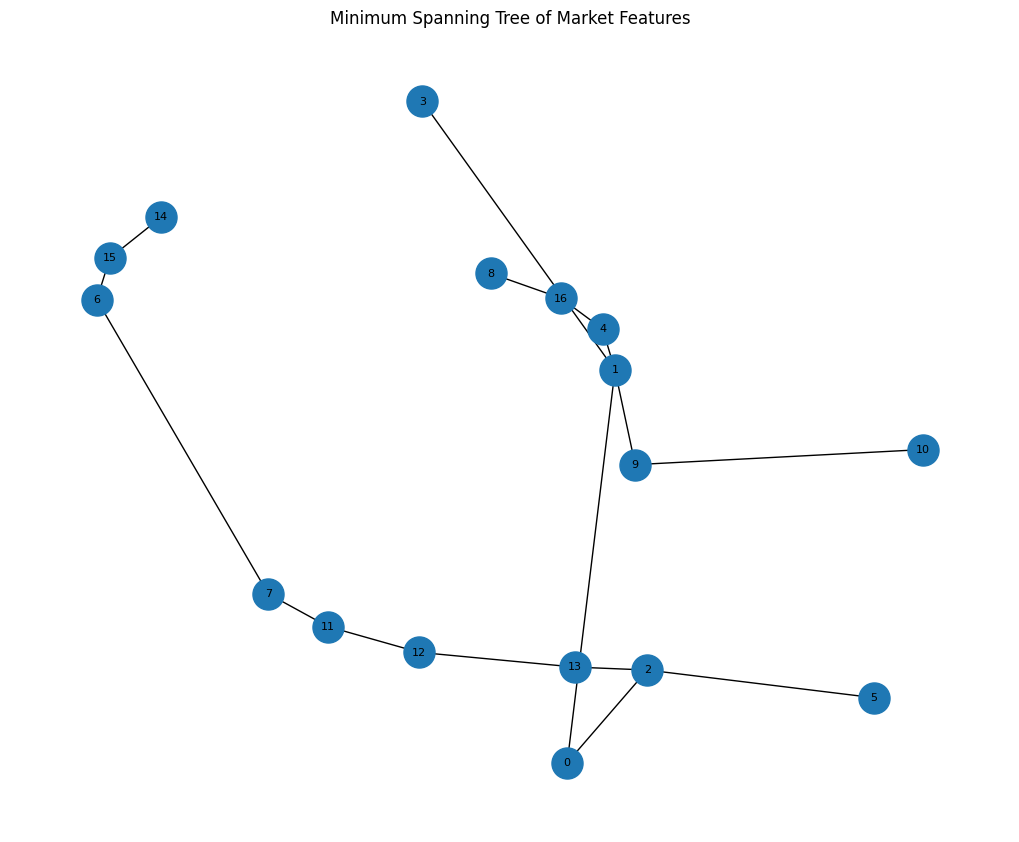

In [53]:
import networkx as nx
from scipy.spatial.distance import squareform

# Use feature correlation
corr = df.drop(columns=["Date"]).corr()

# Convert correlation to distance
distance = np.sqrt(2*(1-corr))

# Build graph
G = nx.from_numpy_array(distance.values)

# Minimum Spanning Tree
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(10,8))
nx.draw(mst, with_labels=True, node_size=500, font_size=8)
plt.title("Minimum Spanning Tree of Market Features")
plt.show()

📊 Cell 26 — Rolling Correlation (Market Synchronization)

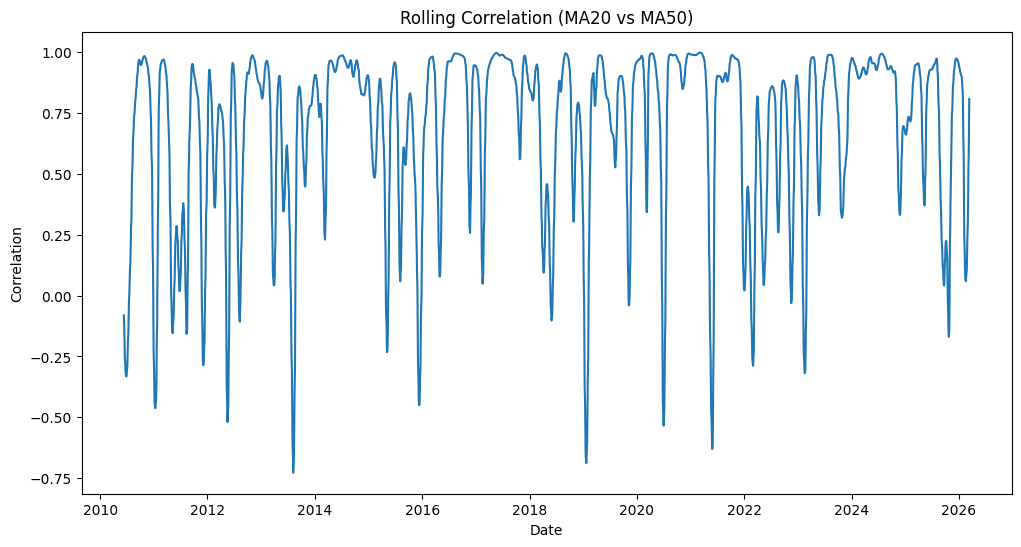

In [54]:
rolling_corr = df["MA_20"].rolling(60).corr(df["MA_50"])

plt.figure(figsize=(12,6))
plt.plot(df["Date"], rolling_corr)
plt.title("Rolling Correlation (MA20 vs MA50)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()

📊 Cell 27 — SHAP Decision Plot

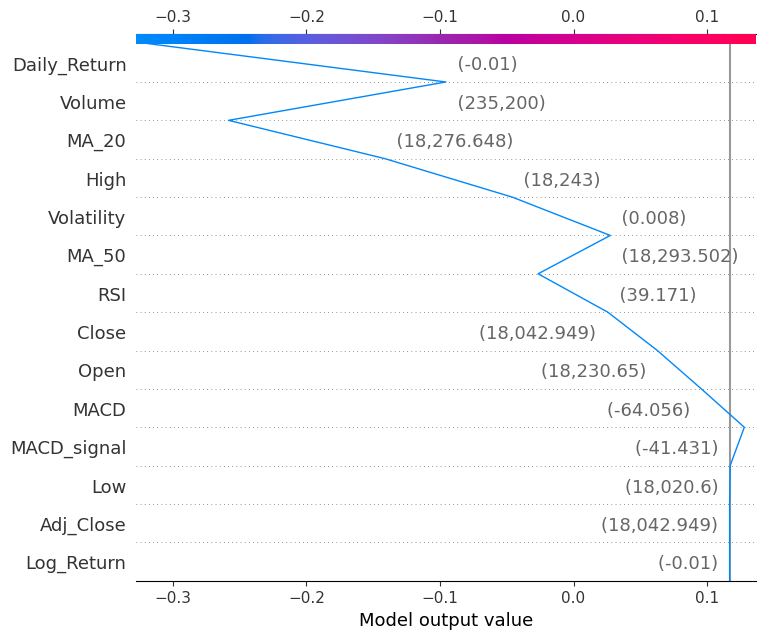

In [57]:
import shap

# create SHAP explainer using the trained model
explainer_shap = shap.TreeExplainer(model)

# compute shap values
shap_values = explainer_shap.shap_values(X_test)

shap.decision_plot(
    explainer_shap.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

Import Classification Models

In [4]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
import pandas as pd
import os

folder = "/kaggle/input/datasets/rick2324/nifty-50-full-features"
file_path = folder + "/" + os.listdir(folder)[0]

df = pd.read_csv(file_path, sep=",")  # force comma separation

print(df.columns)
df.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Adj_Close',
       'Daily_Return', 'Log_Return', 'Volatility', 'MA_20', 'MA_50', 'RSI',
       'MACD', 'MACD_signal', 'Next_Return'],
      dtype='object')


,Date,Close,High,Low,Open,Volume,Adj_Close,Daily_Return,Log_Return,Volatility,MA_20,MA_50,RSI,MACD,MACD_signal,Next_Return
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0,5232.200195,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.008734
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,5277.899902,0.008734,0.008696,NaN,NaN,NaN,NaN,3.645561,0.729112,0.000739
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,5281.799805,0.000739,0.000739,NaN,NaN,NaN,NaN,6.771328,1.937555,-0.003540
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,5263.100098,-0.003540,-0.003547,NaN,NaN,NaN,NaN,7.651410,3.080326,-0.003487
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,5244.750000,-0.003487,-0.003493,NaN,NaN,NaN,NaN,6.789912,3.822243,0.000887


In [18]:
df["Next_Direction"] = (df["Next_Return"] > 0).astype(int)

In [22]:
# remove rows containing NaN values
df = df.dropna()

print("New dataset shape:", df.shape)

New dataset shape: (3928, 17)


In [23]:
from sklearn.model_selection import train_test_split

features = df.drop(columns=["Date", "Next_Return", "Next_Direction"])
target = df["Next_Direction"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(3142, 14) (786, 14)


Train SVM Model

In [26]:
svm_model = SVC(kernel="rbf", probability=True)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.544529262086514


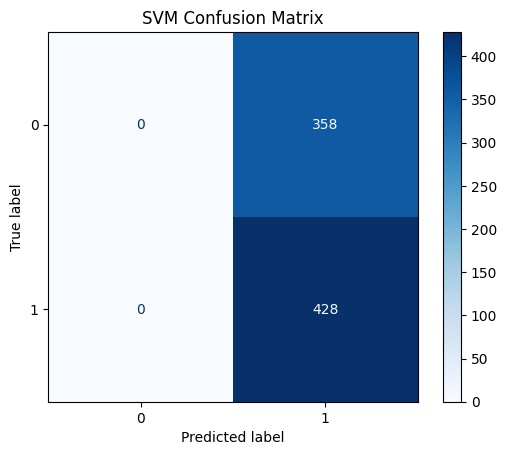

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

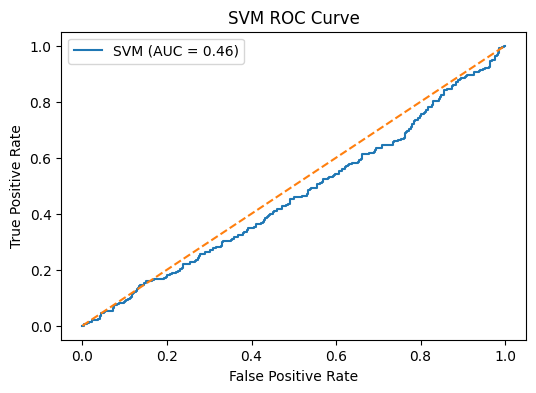

In [28]:
from sklearn.metrics import roc_curve, auc

svm_probs = svm_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, svm_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="SVM (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()

plt.show()

 Train Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.5585241730279898


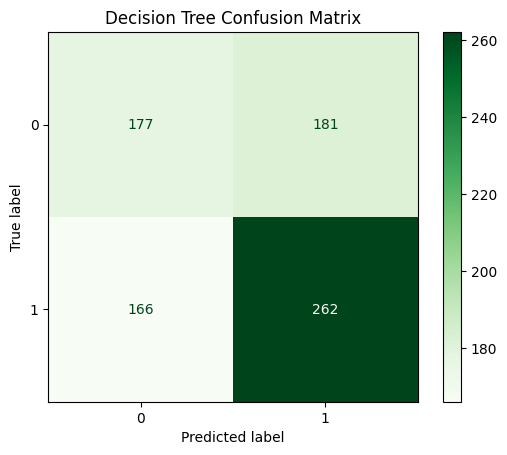

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")

plt.show()

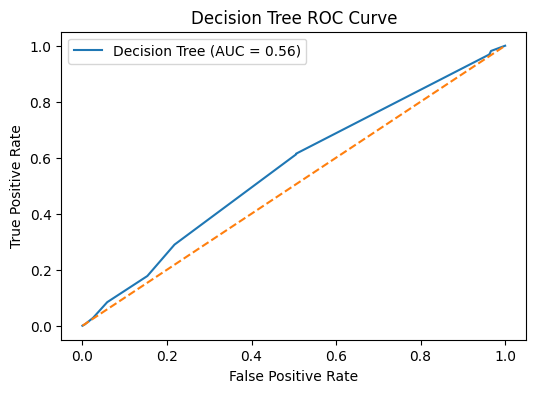

In [37]:
from sklearn.metrics import roc_curve, auc

dt_probs = dt_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, dt_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Decision Tree (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

Train Random Forest

In [6]:
import pandas as pd
import os

folder = "/kaggle/input/datasets/rick2324/nifty-50-full-features"
file_path = folder + "/" + os.listdir(folder)[0]

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(3978, 16)


,Date,Close,High,Low,Open,Volume,Adj_Close,Daily_Return,Log_Return,Volatility,MA_20,MA_50,RSI,MACD,MACD_signal,Next_Return
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0,5232.200195,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.008734
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,5277.899902,0.008734,0.008696,NaN,NaN,NaN,NaN,3.645561,0.729112,0.000739
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,5281.799805,0.000739,0.000739,NaN,NaN,NaN,NaN,6.771328,1.937555,-0.003540
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,5263.100098,-0.003540,-0.003547,NaN,NaN,NaN,NaN,7.651410,3.080326,-0.003487
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,5244.750000,-0.003487,-0.003493,NaN,NaN,NaN,NaN,6.789912,3.822243,0.000887


In [16]:
df = df.dropna()
df["Next_Direction"] = (df["Next_Return"] > 0).astype(int)

In [30]:
from sklearn.model_selection import train_test_split

features = df.drop(columns=["Date", "Next_Return", "Next_Direction"])
target = df["Next_Direction"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.5419847328244275


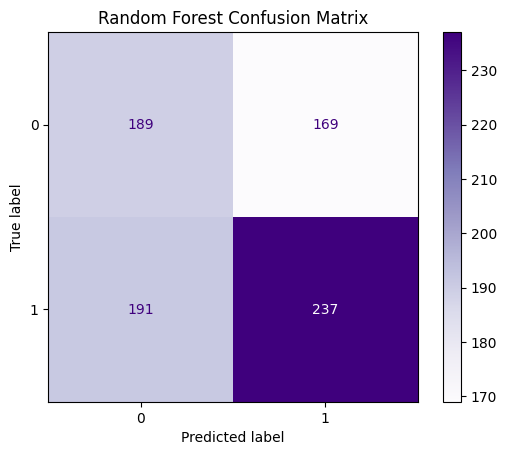

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Purples")
plt.title("Random Forest Confusion Matrix")

plt.show()

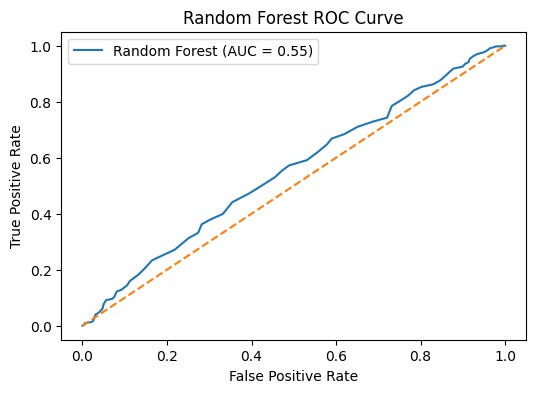

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

Accuracy Comparison Graph

In [40]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", probability=True)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)


from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.544529262086514


In [44]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5585241730279898


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.5419847328244275


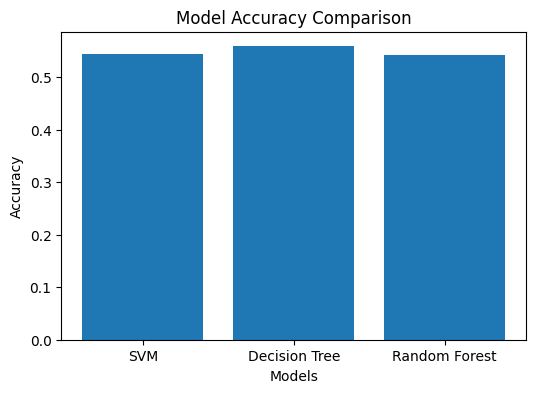

In [47]:
import matplotlib.pyplot as plt

models = ["SVM", "Decision Tree", "Random Forest"]
accuracies = [svm_accuracy, dt_accuracy, rf_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

Import KMeans

In [56]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [68]:
cluster_features = df[[
    "Daily_Return",
    "Volatility",
    "RSI",
    "MACD"
]]

In [71]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_features)

In [72]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_cluster)

print(df["Cluster"].value_counts())

Cluster
0    1866
1    1526
2     536
Name: count, dtype: int64


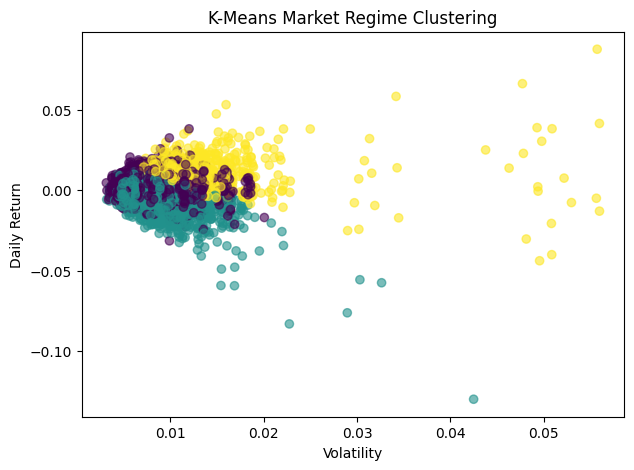

In [73]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Volatility"],
    df["Daily_Return"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Volatility")
plt.ylabel("Daily Return")
plt.title("K-Means Market Regime Clustering")

plt.show()